# Statistische Analyse der Häufigkeiten an Unterbrechungen

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [2]:
#parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'KPD', 'BP', 'DP', 'WAV', 'Z', 'fraktionslos' ]
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'fraktionslos']

In [3]:
df_interruptions = pd.read_csv('./data/comments.csv')

In [4]:
df_interruptions.head(-20)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der W...,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist doch die erste Lesung!,CDU/CSU,<unknown>,DIE LINKE,Dr. Barbara Höll,1991-03-12,11,2
3,3,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
4,4,Gebt erst mal das Vermögen der PDS dem Staat ...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
...,...,...,...,...,...,...,...,...,...
467898,467898,Was ist jetzt hier der Unterschied zwischen A...,CDU/CSU,Markus Grübel,GRÜNE,Tobias B. Bacherle,2024-05-16,26,223492
467899,467899,Es gilt das Völkerrecht!,CDU/CSU,<unknown>,GRÜNE,Tobias B. Bacherle,2024-05-16,26,223492
467900,467900,Ach!,AfD,<unknown>,SPD,Emily Vontz,2024-05-16,33,223493
467901,467901,Oijoijoi!,SPD,Brian Nickholz,CDU/CSU,Anne König,2024-05-16,30,223494


# Anzahl der Zwischenrufe im Zeitverlauf

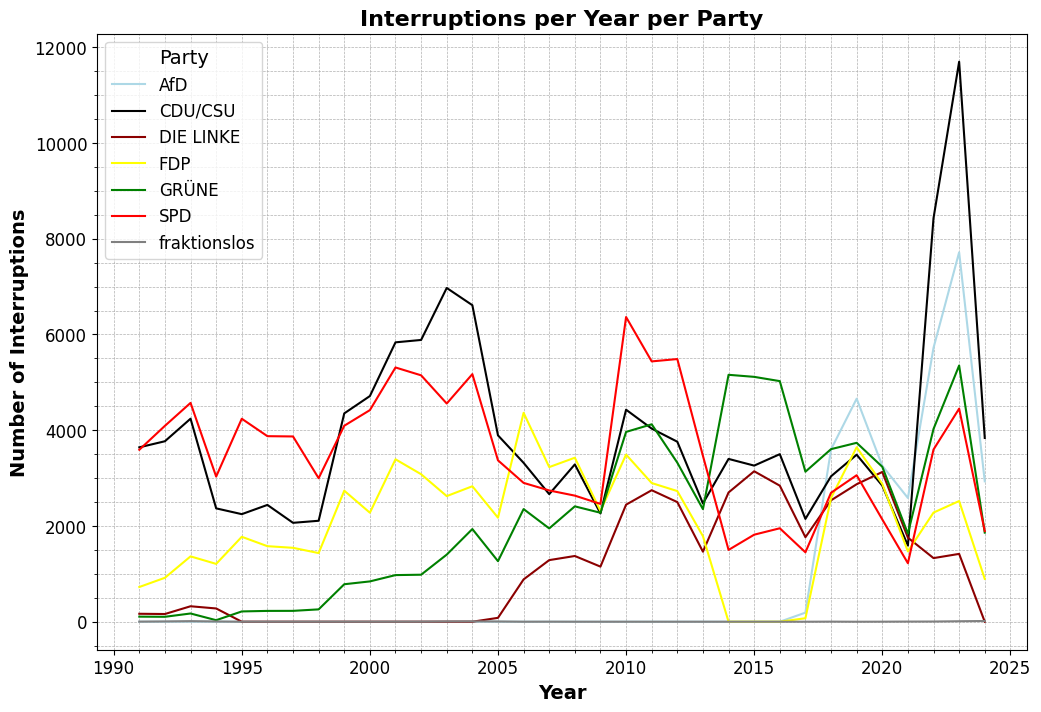

In [5]:
df_interruptions['date'] = pd.to_datetime(df_interruptions['date'])

df_interruptions['year'] = df_interruptions['date'].dt.year

interruptions_per_year = df_interruptions.groupby(['year', 'comment_party']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))

party_colors = {
    'CDU/CSU': 'black',
    'AfD': 'lightblue',
    'DIE LINKE': 'darkred',
    'SPD': 'red',
    'GRÜNE': 'green',
    'FDP': 'yellow',
    'fraktionslos': 'grey'
}

for party in interruptions_per_year.columns:
    color = party_colors.get(party, 'black')
    sns.lineplot(data=interruptions_per_year, x=interruptions_per_year.index, y=party, label=party, color= color )

plt.xlabel('Year', fontsize=14, weight='bold')
plt.ylabel('Number of Interruptions', fontsize=14, weight='bold')
plt.title('Interruptions per Year per Party', fontsize=16, weight='bold')
plt.legend(title='Party', fontsize=12, title_fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=10)

plt.show()

TODO: Analyse

# Zwischenrufe pro Zeitperiode

In [6]:
def get_interruption_count_for_timespan(start_date, end_date):
    relevant_comments = df_interruptions[ (df_interruptions['date'] >=start_date) & (df_interruptions['date']  <= end_date)]
    
    custom_order = parties

    num_interruptions = relevant_comments.groupby('comment_party').size().reset_index(name='num_of_interruptions')

    # Set the index to 'comment_party' and reorder the rows
    num_interruptions = num_interruptions.set_index('comment_party').reindex(custom_order)

    return num_interruptions

In [7]:
start_date, end_date = '2021-09-14', '2024-05-24'
df_interruptions_num = get_interruption_count_for_timespan(start_date, end_date)
df_interruptions_num

,num_of_interruptions
comment_party,
CDU/CSU,24241
SPD,10112
GRÜNE,11392
FDP,5883
AfD,16713
DIE LINKE,2831
fraktionslos,29


In [8]:
# plotly because interactive hovering above charts
def plot_interruption_numbers_per_party(df_interruptions_num, norm=False):
    # Extract party names and interruption counts
    parties = df_interruptions_num.index
    comments_per_party = df_interruptions_num['num_of_interruptions']

    # Define colors for each party
    party_colors = {
        'CDU/CSU': 'black',
        'SPD': 'red',
        'GRÜNE': 'green',
        'FDP': 'yellow',
        'AfD': 'blue',
        'DIE LINKE': 'red',
        'fraktionslos': 'gray'
    }

    # Farben...
    fig = go.Figure(data=[go.Bar(x=parties, y=comments_per_party, marker_color=[party_colors[party] for party in parties])])


    yaxis = dict(autorange=True)
    title = 'Number of Interruptions by Party'
    if not norm:
        yaxis['title'] = 'Number of Interruptions'
    else:
        title = 'Number of Interruptions normalized by Party Seats'
        yaxis['title'] = 'Number of Interruptions per Member of Parliament'

    fig.update_layout(title=title,
                      xaxis_title="Party",
                      xaxis=dict(tickangle=-45),
                      yaxis=yaxis
                      )

    # Show the figure
    fig.show()
plot_interruption_numbers_per_party(df_interruptions_num)

Im 20. Bundestag gab es zum Zeitpunkt dieser Daten 170 Sitzungen.  
    - Das macht für z.B. die Union 24241/170 = 142 Unterbrechungen/Sitzung.  
    - Bei der AfD sind es 16713/170 = 98 Unterbrechungen/Sitzung.   
Wir finden, das ist schon ziemlich viel.

Absolute Zahlen sind zwar schön, erzählen aber nicht die ganze Geschichte. In der Linken Fraktion sitzen ja deutlich weniger Abgeordnete, als in der Union.

In [9]:
second_votes = [0.241, 0.257, 0.148, 0.115, 0.103, 0.049] # in correct order for this NB, 20. BT
abgeordnete_absolute_nums =  [percentage * 733 for percentage in second_votes] # Seats in the 20th BT
df_interruptions_num_norm_seats = df_interruptions_num.drop(index='fraktionslos').div(abgeordnete_absolute_nums, axis=0)
df_interruptions_num_norm_seats['num_of_interruptions'] = df_interruptions_num_norm_seats['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats, norm=True)

Hier zeigt sich noch eine deutlichere Kluft. Im Schnitt hat jeder Abgeordnete der AfD alleine in dieser Wahlperiode schon 221 mal hineingerufen. Das ist über 4 mal so viel, wie bei den Abgeordneten der SPD.

# Wer ruft wem überhaupt rein?

Die folgenden - unübersichtlichen - Pandas-Kommandos errechnen aus unserem comments-dataframe eine quadratische Matrix, in der die Unterbrechungen aufgeschlüsselt sind. Das Ganze ist mit start- und Enddatum einschränkbar.  
Zusätzlich wird berechnet, wie viele Sätze die Redner-Partei im gegebenen Zeitraum gesprochen hat. Damit können wir dann auch nach Redeanteil normalisieren.

In [10]:
def get_interrupt_matrix_for_timespan(start_date, end_date):
    relevant_comments = df_interruptions[ (df_interruptions['date'] >=start_date) & (df_interruptions['date']  <= end_date)]

    df_unique_speeches = relevant_comments.drop_duplicates(subset=['interrupted_speaker_party', 'speech_id'])
    df_sum_speech_len_sents = df_unique_speeches.groupby('interrupted_speaker_party')['speech_len_sents'].sum().reset_index()
    df_sum_speech_len_sents.columns = ['Party', 'Total_Speech_Length_Sents']
    df_sum_speech_len_sents = df_sum_speech_len_sents.set_index('Party').reindex(parties)

    interruption_matrix = pd.crosstab(relevant_comments['comment_party'], relevant_comments['interrupted_speaker_party']) # pretty handy function...

    interruption_matrix = interruption_matrix.reindex(parties, axis=1)
    interruption_matrix = interruption_matrix.reindex(parties, axis=0)

    return interruption_matrix.T, df_sum_speech_len_sents

start_date, end_date = '1991-03-14', '2024-05-24'
start_date, end_date = '2021-09-14', '2024-05-24'
interruption_matrix, sentence_counts = get_interrupt_matrix_for_timespan(start_date, end_date)
#interruption_matrix
sentence_counts

,Total_Speech_Length_Sents
Party,
CDU/CSU,172641
SPD,161533
GRÜNE,96928
FDP,77129
AfD,77301
DIE LINKE,37700
fraktionslos,5940


In [11]:
interruption_matrix

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE,fraktionslos
interrupted_speaker_party,,,,,,,
CDU/CSU,2933,5092,6295,3057,2623,720,1
SPD,8892,862,573,424,5874,495,5
GRÜNE,6105,320,546,236,3946,296,7
FDP,4373,341,367,442,2276,468,2
AfD,864,2900,2977,1001,920,457,3
DIE LINKE,945,412,435,633,994,380,0
fraktionslos,129,185,199,90,80,15,11


Normalize with sentences spoken by speaker party

In [12]:
interruption_matrix_norm_sents = interruption_matrix.div(np.array(sentence_counts))
interruption_matrix_norm_sents

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE,fraktionslos
interrupted_speaker_party,,,,,,,
CDU/CSU,0.016989,0.029495,0.036463,0.017707,0.015193,0.004171,0.000006
SPD,0.055048,0.005336,0.003547,0.002625,0.036364,0.003064,0.000031
GRÜNE,0.062985,0.003301,0.005633,0.002435,0.040711,0.003054,0.000072
FDP,0.056697,0.004421,0.004758,0.005731,0.029509,0.006068,0.000026
AfD,0.011177,0.037516,0.038512,0.012949,0.011902,0.005912,0.000039
DIE LINKE,0.025066,0.010928,0.011538,0.016790,0.026366,0.010080,0.000000
fraktionslos,0.021717,0.031145,0.033502,0.015152,0.013468,0.002525,0.001852



Das zeigt immer noch nicht das ganze Bild. Schließlich gibt es in der CDU/CSU-Fraktion mehr als doppelt so viele Menschen wie in der AfD-Fraktion. Also normalisieren wir nach der Anzahl der Sitze. Die Prozentsätze der Zweitstimmen finden sich hier.

Normalisieren nach der Anzahl der Sitze bedeutet, die Spalten durch den Stimmenanteil zu teilen -> geringerer Stimmenanteil -> Score wird höher. Leider verlieren wir etwas an Interpretierbarkeit, weil es nicht mehr nur einfache Unterbrechungen pro Satz sind und die resultierende Einheit (Unterbrechungen/Satz)/Sprecher etwas seltsam ist.

Anmerkung: Der Einfachheit halber lassen wir fraktionslose Abgeordnete weg. Deren Zahlen sind nicht all zu interessant und die Berechnung der nächsten Teile wäre unnötig kompliziert, wenn man diese mitschleifen müsste

In [13]:
interruption_matrix_norm_sents = interruption_matrix_norm_sents.drop(labels='fraktionslos')
interruption_matrix_norm_sents = interruption_matrix_norm_sents.drop(columns='fraktionslos')

interruption_matrix_norm_sents_seats = interruption_matrix_norm_sents.div(abgeordnete_absolute_nums, axis=1)
interruption_matrix_norm_sents_seats

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE
interrupted_speaker_party,,,,,,
CDU/CSU,0.000096,0.000157,0.000336,0.000210,0.000201,0.000116
SPD,0.000312,0.000028,0.000033,0.000031,0.000482,0.000085
GRÜNE,0.000357,0.000018,0.000052,0.000029,0.000539,0.000085
FDP,0.000321,0.000023,0.000044,0.000068,0.000391,0.000169
AfD,0.000063,0.000199,0.000355,0.000154,0.000158,0.000165
DIE LINKE,0.000142,0.000058,0.000106,0.000199,0.000349,0.000281


## Plotten

Jetzt, da die Werte vergleichbar sind, haben sie auch einen schönen Plot verdient.  
Der wurde von oben aufgespart, damit man die Plots ohne viel Scrollen nah beieinander hat.  
Reihenfolge: Nicht normalisiert, normalisiert nach Redeanteil (Anzahl Sätze), normalisiert nach Sitzen, normalisiert nach Sitzen und Redeanteil.

In [14]:
def plot_interruption_matrix(interruption_matrix):
    plt.figure(figsize=(7,7))
    sns.set_style("whitegrid")

    ax = sns.heatmap(interruption_matrix, cmap="Blues", annot=False, cbar=True, square=True, cbar_kws={'shrink': 0.8})

    # Rotate x-axis labels
    if len(interruption_matrix.columns) < len(parties): # ohne Fraktionslose Abgeordnete
        ax.set_xticklabels(parties[:-1], rotation=20)
        # Rotate x-axis labels
        ax.set_yticklabels(parties[:-1], rotation=0)
    else:
        ax.set_xticklabels(parties, rotation=20)
        ax.set_yticklabels(parties, rotation=0)

    # Set y-axis labels to the top
    ax.xaxis.set_ticks_position('top')
    
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Interruptor Party', labelpad=5)
    ax.set_ylabel('Speaker Party', labelpad=5)

    plt.title('Interruptions in the German Bundestag', pad=20)
    plt.show()


#### Absolute Zahlen:

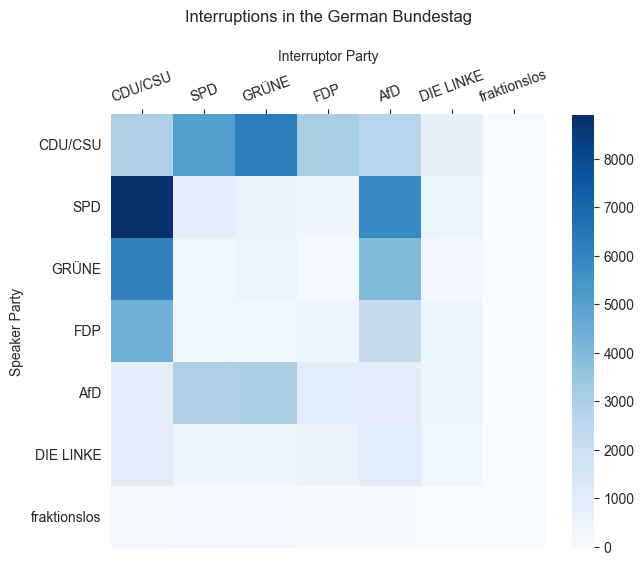

In [15]:
plot_interruption_matrix(interruption_matrix)

#### Normalisiert nach Anzahl der insgesamt gesprochenen Sätze der Redner-Partei

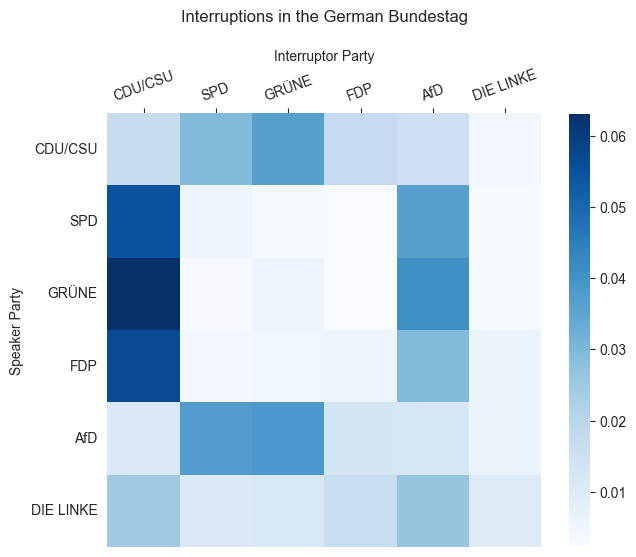

In [16]:
plot_interruption_matrix(interruption_matrix_norm_sents)

#### Normalisiert nach Anzahl der Sitze der Unterbrecher-Partei

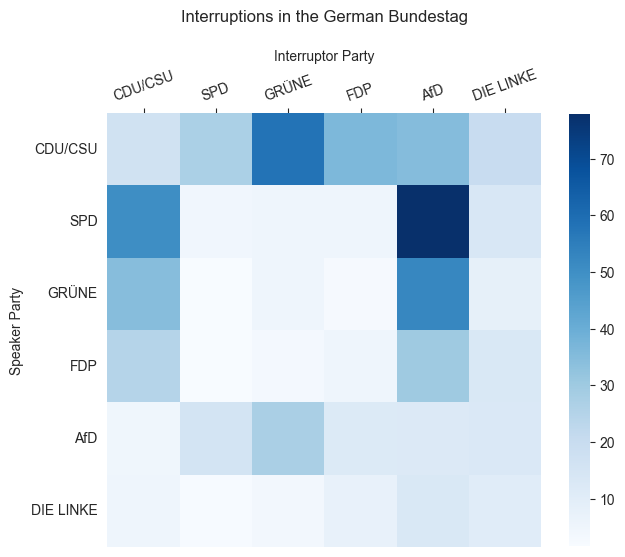

In [17]:
interruption_matrix_norm_seats = interruption_matrix.drop(columns='fraktionslos').drop(index='fraktionslos').div(abgeordnete_absolute_nums, axis=1)
plot_interruption_matrix(interruption_matrix_norm_seats)

#### Normalisiert nach Anzahl der Sätze der Redner-Partei und Anzahl der Sitze der Unterbrecher-Partei

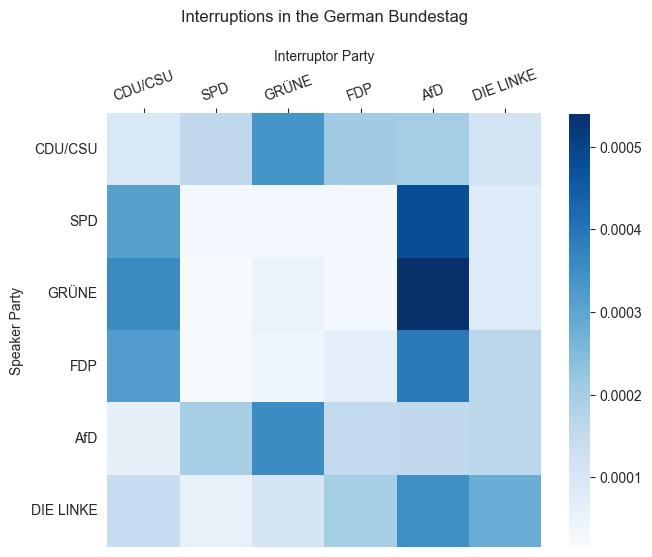

In [18]:
plot_interruption_matrix(interruption_matrix_norm_sents_seats)

Man sieht schon: Je nach Art der Normalisierung liest man unterschiedliche Dinge heraus. Auch das Interpretieren fällt bei den ersten 3 Plots leichter, als beim letzten.

# Andere Bundestagsperioden  

Zum Glück sind die oberen Methoden so geschrieben, dass sich die Analysen leicht auf andere Zeiträume abbilden lassen ;)

## 19. Bundestag

In [19]:
start_date_19, end_date_19 = '2017-10-24', '2021-09-07'
df_interruptions_num_19 = get_interruption_count_for_timespan(start_date_19, end_date_19)
plot_interruption_numbers_per_party(df_interruptions_num_19)

Interessant, oder? Während im 20. Bundestag jetzt schon (über 1 Jahr vor dem Ende) fast 25k Unterbrechungen von der Union und über 16k Unterbrechungen von der AfD gemacht wurden, so ist es im 19. Bundestag deutlich ausgeglichener.  
Fast alle Parteien finden sich so um bis etwas über der 10k-Marke.  
Ist der Ton im Bundestag wohl mit dem Ende der GroKo rauer geworden? Vor allem bei den Nicht-Koalitionsfraktionen Union und AfD ist, hat die Frequenz der Zwischenrufe nochmal gut angezogen.

In [20]:
second_votes_19 = [0.329, 0.205, 0.089, 0.107, 0.126, 0.092]
num_all_seats_19 = 709
abgeordnete_absolute_nums_19 =  [percentage * num_all_seats_19 for percentage in second_votes_19] # Seats in the 20th BT
df_interruptions_num_norm_seats_19 = df_interruptions_num_19.drop(index='fraktionslos').div(abgeordnete_absolute_nums_19, axis=0)
df_interruptions_num_norm_seats_19['num_of_interruptions'] = df_interruptions_num_norm_seats_19['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats_19, norm=True)

Die Union war also nicht schon immer so ein Störenfried. Wenn man selbst an der Regierung beteiligt ist, weicht ja auch weniger von der eigenen Parteilinie ab.  
Was auch hervorsticht, ist, dass DIE LINKE (pro Sitz) in der letzten Wahlperiode deutlich öfter dazwischengerufen hat. Der Verlust ihrer Fraktion (Als Fraktion gilt man erst ab 5%) hat ihnen in der 20. Wahlperiode wohl zu schaffen gemacht.

In [21]:
interruption_matrix_19, sentence_counts_19 = get_interrupt_matrix_for_timespan(start_date_19, end_date_19)

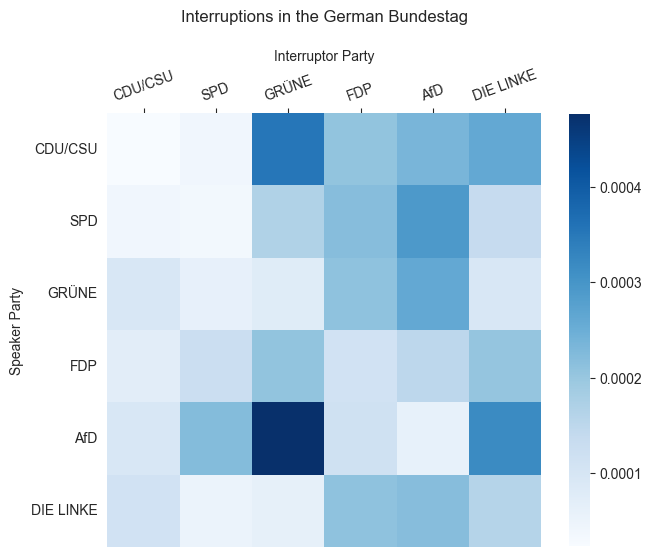

In [22]:
interruption_matrix_norm_sents_19 = interruption_matrix_19.div(np.array(sentence_counts_19))
interruption_matrix_norm_sents_19 = interruption_matrix_norm_sents_19.drop(labels='fraktionslos').drop(columns='fraktionslos')
interruption_matrix_norm_sents_seats_19 = interruption_matrix_norm_sents_19.div(abgeordnete_absolute_nums_19, axis=1)
plot_interruption_matrix(interruption_matrix_norm_sents_seats_19)

## 18. Bundestag

In [23]:
start_date_18, end_date_18 = '2013-10-22', '2017-09-05'
df_interruptions_num_18 = get_interruption_count_for_timespan(start_date_18, end_date_18)
plot_interruption_numbers_per_party(df_interruptions_num_18)

Nur 4 Parteien. AfD und FDP sind mit jeweils weniger als einem halben Prozent am Bundestag vorbeigeschlittert. 
Interessant ist hier auch, dass die Grünen mit nur 8,4 % über 18k Zwischenrufe haben.  
Näheres dazu kommt aber im nächsten Plot

In [24]:
second_votes_18 = [0.415, 0.257, 0.084, 0.048, 0.047, 0.086]
num_all_seats_18 = 709
abgeordnete_absolute_nums_18 =  [percentage * num_all_seats_18 for percentage in second_votes_18] # Seats in the 20th BT
df_interruptions_num_norm_seats_18 = df_interruptions_num_18.drop(index='fraktionslos').div(abgeordnete_absolute_nums_18, axis=0)
df_interruptions_num_norm_seats_18['num_of_interruptions'] = df_interruptions_num_norm_seats_18['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats_18, norm=True)

Kompletter Ausreißer sind hier die Grünen über 300 Zwischenrufen pro Sitz im Bundestag. Das ist schon eine Ansage. Im 18. BT gab es 245 Sitzungen, es ist also im Schnitt jeder Abgeordnete in jeder Sitzung dem Redner mehr als ein mal ins Wort gefallen. Und das ohne, dass man die Abwesenheiten miteinbezieht...

In [25]:
interruption_matrix_18, sentence_counts_18 = get_interrupt_matrix_for_timespan(start_date_18, end_date_18)
interruption_matrix_18.loc['FDP',:] = float("nan")
interruption_matrix_18.loc[:,'FDP'] = float("nan")
sentence_counts_18.loc['FDP'] = float("nan")
# Sonderfall FDP. In einer der ersten Sitzungen spricht auch die sich damals noch im Amt befindende Staatsministerin im Auswärtigen Amt, Cornelia Pieper (FDP)
# Deswegen bereinigung der FDP-Zeilen + Spalten

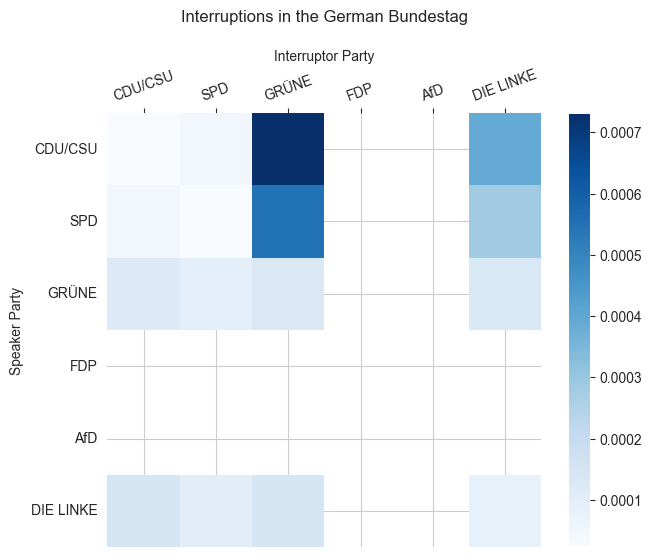

In [26]:
interruption_matrix_norm_sents_18 = interruption_matrix_18.div(np.array(sentence_counts_18))
interruption_matrix_norm_sents_18 = interruption_matrix_norm_sents_18.drop(labels='fraktionslos').drop(columns='fraktionslos')
interruption_matrix_norm_sents_seats_18 = interruption_matrix_norm_sents_18.div(abgeordnete_absolute_nums_18, axis=1)
plot_interruption_matrix(interruption_matrix_norm_sents_seats_18)

Grüne und Linke (beide Opposition) haben sich also vorrangig gegen die eher stille GroKo geäußert.

### Zeitsprung zu 1991

Kurz nach der Wiedervereinigung. Viele Zwischenrufe gehen gegen die PDS (Nachfolgepartei der SED), welche bald mit der Linken fusioniert. Streitthema ist v.a. das Parteivermögen, das sich auf 6,2 Milliarden DDR-Mark belief und bei der Fusion an die Linken überging.  

Weil leider im März 1991 das Format angepasst wurde, sind die Daten über diese Wahlperiode nicht vollständig. Sie beginnen ab der 15. Sitzung (von insgesamt 243).

In [28]:
start_date_12, end_date_12 = '1991-03-14', '1994-09-21'
df_interruptions_num_12 = get_interruption_count_for_timespan(start_date_12, end_date_12)
plot_interruption_numbers_per_party(df_interruptions_num_12)

Die Normalisierung nach Sitzen geht hier nicht so schön mit Berechnungen.  
Nach der Wiedervereinigung gab es einige Sonderregelungen. Deswegen eine Liste von [hier](https://de.wikipedia.org/wiki/12._Deutscher_Bundestag)

In [29]:
abgeordnete_absolute_nums_12 =  [319, 239, 8, 79, 0, 17]# Seats in the 12th BT
df_interruptions_num_norm_seats_12 = df_interruptions_num_12.drop(index='fraktionslos').div(abgeordnete_absolute_nums_12, axis=0)
df_interruptions_num_norm_seats_12['num_of_interruptions'] = df_interruptions_num_norm_seats_12['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats_12, norm=True)

Obwohl hier durch die wenig aussagekräftige Mitgliederanzahl der Grünen und der linken (PDS) bei der Normalisierung leicht ein verzerrtes Bild hätte aufkommen können, schwanken alle Parteien um die 50+-12 Zurufen/Sitz

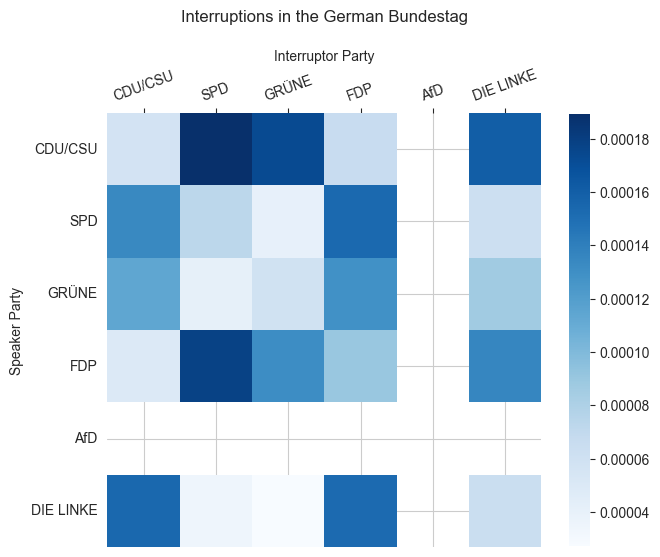

In [31]:
interruption_matrix_12, sentence_counts_12= get_interrupt_matrix_for_timespan(start_date_12, end_date_12)
interruption_matrix_norm_sents_12 = interruption_matrix_12.div(np.array(sentence_counts_12))
interruption_matrix_norm_sents_12 = interruption_matrix_norm_sents_12.drop(labels='fraktionslos').drop(columns='fraktionslos')
interruption_matrix_norm_sents_seats_12 = interruption_matrix_norm_sents_12.div(abgeordnete_absolute_nums_12, axis=1)
plot_interruption_matrix(interruption_matrix_norm_sents_seats_12)

Eine interessante Aufgabe ist es, aus diesen Plots herauszulesen, wer denn gerade in der Koalition, und wer in der Opposition ist.  
Das ist hier auch relativ machbar ;)

<details>
<summary>Lösung</summary>

**Koalition**: Union und FDP  
**Opposition**: SPD, Grüne, LINKE/PDS  

Erklärung: Normalerweise unterbrechen sich die Parteien, die gemeinsam in der Koalition (oder gemeinsam in der Opposition) sind weniger, als Parteien, die nicht miteinander verbunden sind. Es gibt zwar hin und wieder Unterstützungsrufe aber die Mehrheit der Zwischenrufe ist negativ (siehe Sentimentanalyse).
Das ergibt zwei Gruppen: Gruppe 1: [CDU/CSU, FDP]; Gruppe 2: [SPD, Grüne, DIE LINKE (PDS)]. Weil die Gruppe 2, etwas öfter etwas zusätzlich anmerken muss, kann man ablesen, dass diese vermutlich die Opposition darstellt.  

</details>

# Fazit

Das war die statistische Analyse der Anzahl an Zwischenrufen.

### Erkenntnisse

* Dies letzten beiden Wahlperioden sind besonders von Unterbrechungen geprägt. Die AfD war seitdem sie im Bundestag vertreten ist pro Abgeordneten immer recht laut. Seit dem 20. BT hat auch die Union zu diesem Klima beigetragen. 
* Opposition und Koalition unterbrechen sich oft gegenseitig. Koalitionsparteien unterbrechen sich untereinander aber kaum -> Unterbrechungen scheinen eher negativ zu sein (Ergebnisse der Sentimentanalyse folgen noch)
